In [46]:
import sys
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns
from scipy.stats import skew, kurtosis
from tqdm.auto import tqdm

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT

In [47]:
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]
DISCRETE_FEATURES = ["n_nodes", "n_edges"]
CONTINUOUS_FEATURES = [
    "degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3", 
    "annd_0", "annd_1", "annd_2", "annd_3",
    "eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"
]

def load_generation_data() -> pd.DataFrame:
    """Load and preprocess all original datasets and synthetic variants saving all per-graph statistics."""
    rows = []
    original_stats_map = {}

    for dataset_name in DATASET_NAMES:
        # Load original
        orig_pt_path = PROJECT_ROOT / "data" / dataset_name / f"{dataset_name}_original.pt"
        if orig_pt_path.exists():
            dataset_obj = DatasetPT(orig_pt_path)
            per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])

            for i, stats in enumerate(per_graph_stats):                
                row = {
                    "dataset": dataset_name,
                    "graph_idx": i,
                    "class_id": dataset_obj[i].y.item(),
                }
                # Flatten the stats dictionary
                for key, value in stats.items():
                    if isinstance(value, (list, np.ndarray)):
                        for idx, val in enumerate(value):
                            row[f"{key}_{idx}"] = val
                    else:
                        row[key] = value
                rows.append(row)
        else:
            print(f"Warning: Original dataset not found at {orig_pt_path}")
                        
    df = pd.DataFrame(rows)
    if "seed" in df.columns:
        df["seed"] = df["seed"].astype("Int64")
    return df

# Load data
df = load_generation_data()
display(df.head(5))

DATASETS = [d for d in DATASET_NAMES if d in df["dataset"].unique()]

,dataset,graph_idx,class_id,n_nodes,n_edges,modularity,clustering,assortativity,efficiency,diameter,...,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,0,30,32,0.576660,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.301724,0.280172,0.261084,0.246305
1,BZR,1,0,33,35,0.614286,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.222656,0.242188
2,BZR,2,0,30,32,0.581055,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
3,BZR,3,0,33,35,0.614286,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.226562,0.238281
4,BZR,4,0,30,32,0.572266,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.301724,0.280172,0.261084,0.246305


In [48]:
def _compute_stat_moments(stat_values: np.ndarray, k: int = 4) -> np.ndarray:
    """Compute the k-th moments of the graph statistics.
    
    Args:
        stat_values: Array of graph statistics
        k: Number of moments to compute (mean, variance, skewness, kurtosis)
    Returns:
        Array with the k-th moments (mean, variance, skewness, kurtosis)
    """
    if not 1 <= k <= 4: 
        raise ValueError("k must be between 1 and 4")

    mom_funcs = [np.mean, np.var, skew, lambda x: kurtosis(x, fisher=False)][:k]

    if stat_values.size == 0:
        return np.zeros(k)

    return np.array([mom_func(stat_values) for mom_func in mom_funcs])

def compute_stat_embedding_per_class(df_dataset: pd.DataFrame, stat_encoding_func, k: int = 4) -> pd.DataFrame:
    """Compute the k-th moments of the graph statistics for a single dataset and its classes.
    
    Args:
        df_dataset: DataFrame containing graph statistics for one dataset
        k: Number of moments to compute (mean, variance, skewness, kurtosis)
    Returns:
        DataFrame with the k-th moments for each class in the dataset
    """
    if k > 4 or k <= 0: raise ValueError("k must be between 1 and 4")
    features = DISCRETE_FEATURES + CONTINUOUS_FEATURES
    
    dataset_name = df_dataset["dataset"].iloc[0]
    results = []
    for class_id, group in df_dataset.groupby("class_id"):
        row = {"class_id": class_id}
        for feat in features:
            row[feat] = stat_encoding_func(group[feat].values, k)
        results.append(row)
    
    res = pd.DataFrame(results)
    res.insert(0, "dataset", dataset_name)
    return res

dataset_moments = []
for dataset_name in DATASETS:
    df_subset = df[df["dataset"] == dataset_name]
    dataset_moments.append(compute_stat_embedding_per_class(df_subset, _compute_stat_moments, k=4))

df_moments = pd.concat(dataset_moments, ignore_index=True)
display(df_moments.head())

,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,"[36.51428571428571, 44.681541950113385, 0.4783...","[39.2031746031746, 48.21268833459308, 0.439221...","[0.06276092971936384, 0.0001510951300895635, 0...","[0.0009650169705461324, 9.079022005936042e-08,...","[0.008689624439882164, 0.06330989499490719, -0...","[1.3218733859916822, 0.01044762764400402, -0.6...","[0.0952477971339814, 0.0002756574709241117, 0....","[0.09451312251458292, 0.00017412850011212948, ...","[0.07559653212914774, 0.00018055982789818477, ...","[0.06907517562897025, 0.00019014418298825988, ...","[0.28819237912801227, 0.0013221432479611321, 0...","[0.2794103656784243, 0.0007591045979986735, 1....","[0.2378344022200922, 0.0006676731963274332, -0...","[0.2549158201327165, 0.0011217843728683985, 0...."
1,BZR,1,"[32.50588235294118, 65.2382006920415, -0.23889...","[34.76470588235294, 79.52110726643599, -0.2308...","[0.07341210916615963, 0.0005692990532426099, 1...","[0.0014664022883739871, 1.1915530154597376e-06...","[0.0309192586861808, 0.08860241443438008, -0.5...","[1.2916816229982058, 0.025897203177481027, -1....","[0.11279317680287615, 0.0014068328242852048, 1...","[0.11009147951468563, 0.0012402836689375263, 1...","[0.08909637968143702, 0.0007295182323968613, 1...","[0.08210999264922281, 0.0007835424912629269, 2...","[0.30786532435756503, 0.00317754962841125, 0.6...","[0.29473172582555784, 0.002025421059453167, 0....","[0.25470710112391387, 0.0015126311213349375, 0...","[0.26279587463129245, 0.0020010678496909734, 0..."
2,MUTAG,0,"[13.936507936507937, 10.059460821365585, 1.341...","[14.619047619047619, 12.93424036281179, 1.1358...","[0.16900574176212116, 0.0009758149036020351, -...","[0.004076202526421684, 3.609649518743938e-06, ...","[-0.151307550142164, 0.017309174398550457, -0....","[1.7791312496271663, 0.25034931721656356, 0.07...","[0.23197711352268943, 0.0025535710725877164, -...","[0.203758863135702, 0.0020708228420828305, 0.1...","[0.1910122628805772, 0.0013744364378579497, -0...","[0.1705919734637135, 0.0010850334559849375, -0...","[0.5121879619364271, 0.004757676958003367, 0.9...","[0.42598479897490554, 0.0018803445411768557, -...","[0.3894795742448842, 0.0019601150228493835, 0....","[0.4023039281148548, 0.0038518213792322867, 0...."
3,MUTAG,1,"[19.944, 14.324863999999998, -0.13016660293230...","[22.4, 21.792000000000005, -0.0942738158217323...","[0.12305602316779056, 0.0006485565500975035, 0...","[0.0016801476452355131, 9.117682127243363e-07,...","[-0.39629024284890574, 0.023308778800796938, 0...","[2.0678372369066365, 0.15744886520923326, -0.5...","[0.15351904991704426, 0.0014666920972810883, 1...","[0.14102252962671255, 0.0010219189030575846, 1...","[0.13813460036337563, 0.0008132336305744394, 1...","[0.12542174003214362, 0.0007069225783993939, 1...","[0.43819283409112186, 0.005621739290337833, 0....","[0.36753466841833377, 0.0027357828249570727, 0...","[0.33242211472932026, 0.003216272780109596, 0....","[0.3479390191999661, 0.004149402151715861, 0.5..."


In [49]:
def _sample_stat_moments(moments: np.ndarray, samples: int, rng: np.random.Generator) -> np.ndarray:
    """
    Generates a sample array of specified size that exactly matches the given statistical moments.
    
    Args:
        moments: Array of target moments [mean, variance, skewness, kurtosis]. Length k (1 to 4).
        samples: Number of samples to generate.
        rng: NumPy random generator instance.
    Returns:
        Array of generated samples matching the target moments.
    """
    from scipy.optimize import minimize

    k = len(moments)
    if k == 0 or samples == 0:
        return np.array([])
        
    # Sample from a standard normal distribution
    z = rng.standard_normal(samples)
    
    # If k=1 (only mean), simply shift the sample
    if k == 1:
        return z - np.mean(z) + moments[0]
        
    # If k=2 (mean and variance), standardize and scale (Z-score re-scaling)
    if k == 2:
        z_std = (z - np.mean(z)) / np.std(z)
        return z_std * np.sqrt(moments[1]) + moments[0]
        
    # Cost function for the optimizer (used for k=3 and k=4)
    def loss_function(coeffs):
        x_temp = np.zeros_like(z)
        for i, c in enumerate(coeffs):
            x_temp += c * (z ** i)
            
        current_moments = _compute_stat_moments(x_temp, k)
        weights = 1.0 / (np.abs(moments) + 1e-5) 
        return np.sum(((current_moments - moments) * weights) ** 2)

    # If k=3 (mean, variance, skewness)
    if k == 3:
        # We use a 2nd degree polynomial: c0 + c1*Z + c2*Z^2
        init_coeffs = np.zeros(3)
        init_coeffs[0] = moments[0]
        init_coeffs[1] = np.sqrt(max(moments[1], 1e-8))
        # c2 starts at 0, the optimizer will find the value to generate the skewness
        
    # If k=4 (mean, variance, skewness, kurtosis)
    elif k == 4:
        target_skew, target_kurt = moments[2], moments[3]
        if target_kurt < (target_skew**2 + 1):
            print(f"The requested combination of Skewness ({target_skew:.2f}) "
                          "and Kurtosis ({target_kurt:.2f}) violates the mathematical limits. "
                          "The optimizer will do its best to approximate it.")
        # We use a 3rd degree polynomial: c0 + c1*Z + c2*Z^2 + c3*Z^3
        init_coeffs = np.zeros(4)
        init_coeffs[0] = moments[0]
        init_coeffs[1] = np.sqrt(max(moments[1], 1e-8))
    
    else:
        raise ValueError("The moments array must have a length between 1 and 4.")

    # Run the optimization
    res = minimize(loss_function, init_coeffs, method='Nelder-Mead', options={'maxiter': 5000})
    
    if not res.success:
        print("The optimizer failed to converge perfectly on the target moments.")

    # Build final array with found coefficients
    x_opt = np.zeros_like(z)
    for i, c in enumerate(res.x):
        x_opt += c * (z ** i)
        
    return x_opt

def sample_dataset(df_dataset_moments: pd.DataFrame, samples_per_class: list[int], stat_decoding_func) -> pd.DataFrame:
    """Given the moments per each statistic, sample a synthetic dataset.
    
    Args:
        df_dataset_moments: DataFrame with the moments of the graph statistics for each class
        samples_per_class: List of the number of samples to generate for each class
    Returns:
        DataFrame with the sampled statistics for each class
    """
    features = DISCRETE_FEATURES + CONTINUOUS_FEATURES
    all_samples = []
    
    # Iterate over classes in the moments DataFrame
    for i, (_, row) in enumerate(tqdm(df_dataset_moments.iterrows(), total=len(df_dataset_moments), desc="Sampling classes", leave=False)):
        class_id = row["class_id"]
        # Handle both list and Series/dict for samples_per_class
        if isinstance(samples_per_class, (pd.Series, dict)):
            n_samples = samples_per_class[class_id]
        else:
            n_samples = samples_per_class[i]
        
        # Prepare data for this class
        class_data = {"class_id": np.full(n_samples, class_id)}
        
        for feat in features:
            moms = row[feat]
            samples = stat_decoding_func(moms, n_samples)
            
            # Post-process: DISCRETE_FEATURES must be non-negative integers
            if feat in DISCRETE_FEATURES:
                # n_nodes must be at least 1, n_edges at least 0
                lower_bound = 1 if feat == "n_nodes" else 0
                samples = np.round(np.maximum(lower_bound, samples)).astype(int)
            
            class_data[feat] = samples
            
        all_samples.append(pd.DataFrame(class_data))
        
    return pd.concat(all_samples, ignore_index=True)

dataset_samples = []
for dataset_name in DATASETS:
    target_moments = df_moments[df_moments["dataset"] == dataset_name]
    samples_per_class = df[df["dataset"] == dataset_name].groupby("class_id").size().to_dict()
    rng = np.random.default_rng(seed=42)
    
    def decoding_func(moms, samples):
        return _sample_stat_moments(moms, samples, rng)
    
    df_s = sample_dataset(target_moments, samples_per_class, decoding_func)
    df_s.insert(0, "dataset", dataset_name)
    dataset_samples.append(df_s)

df_synthetic = pd.concat(dataset_samples, ignore_index=True)
display(df_synthetic.head())

Sampling classes:   0%|          | 0/2 [00:00<?, ?it/s]

Sampling classes:   0%|          | 0/2 [00:00<?, ?it/s]

,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,39,37,0.084345,0.000799,0.266182,1.201418,0.115881,0.089636,0.071365,0.065987,0.301076,0.349226,0.250829,0.205830
1,BZR,0,29,39,0.102611,0.001021,0.075923,1.347318,0.081727,0.087975,0.102684,0.074695,0.254338,0.319384,0.187860,0.273644
2,BZR,0,42,34,0.057406,0.000140,0.229550,1.432605,0.076451,0.097946,0.071377,0.070366,0.307008,0.247051,0.215459,0.284601
3,BZR,0,44,47,0.042415,0.001039,-0.066483,1.066663,0.066544,0.100171,0.053970,0.083868,0.284784,0.321796,0.274778,0.268926
4,BZR,0,25,31,0.058419,-0.000156,0.039067,1.376838,0.090618,0.088198,0.105992,0.068340,0.265921,0.302509,0.286089,0.242613


Computing synthetic embeddings...

----------------------------------------
Dataset: BZR
----------------------------------------


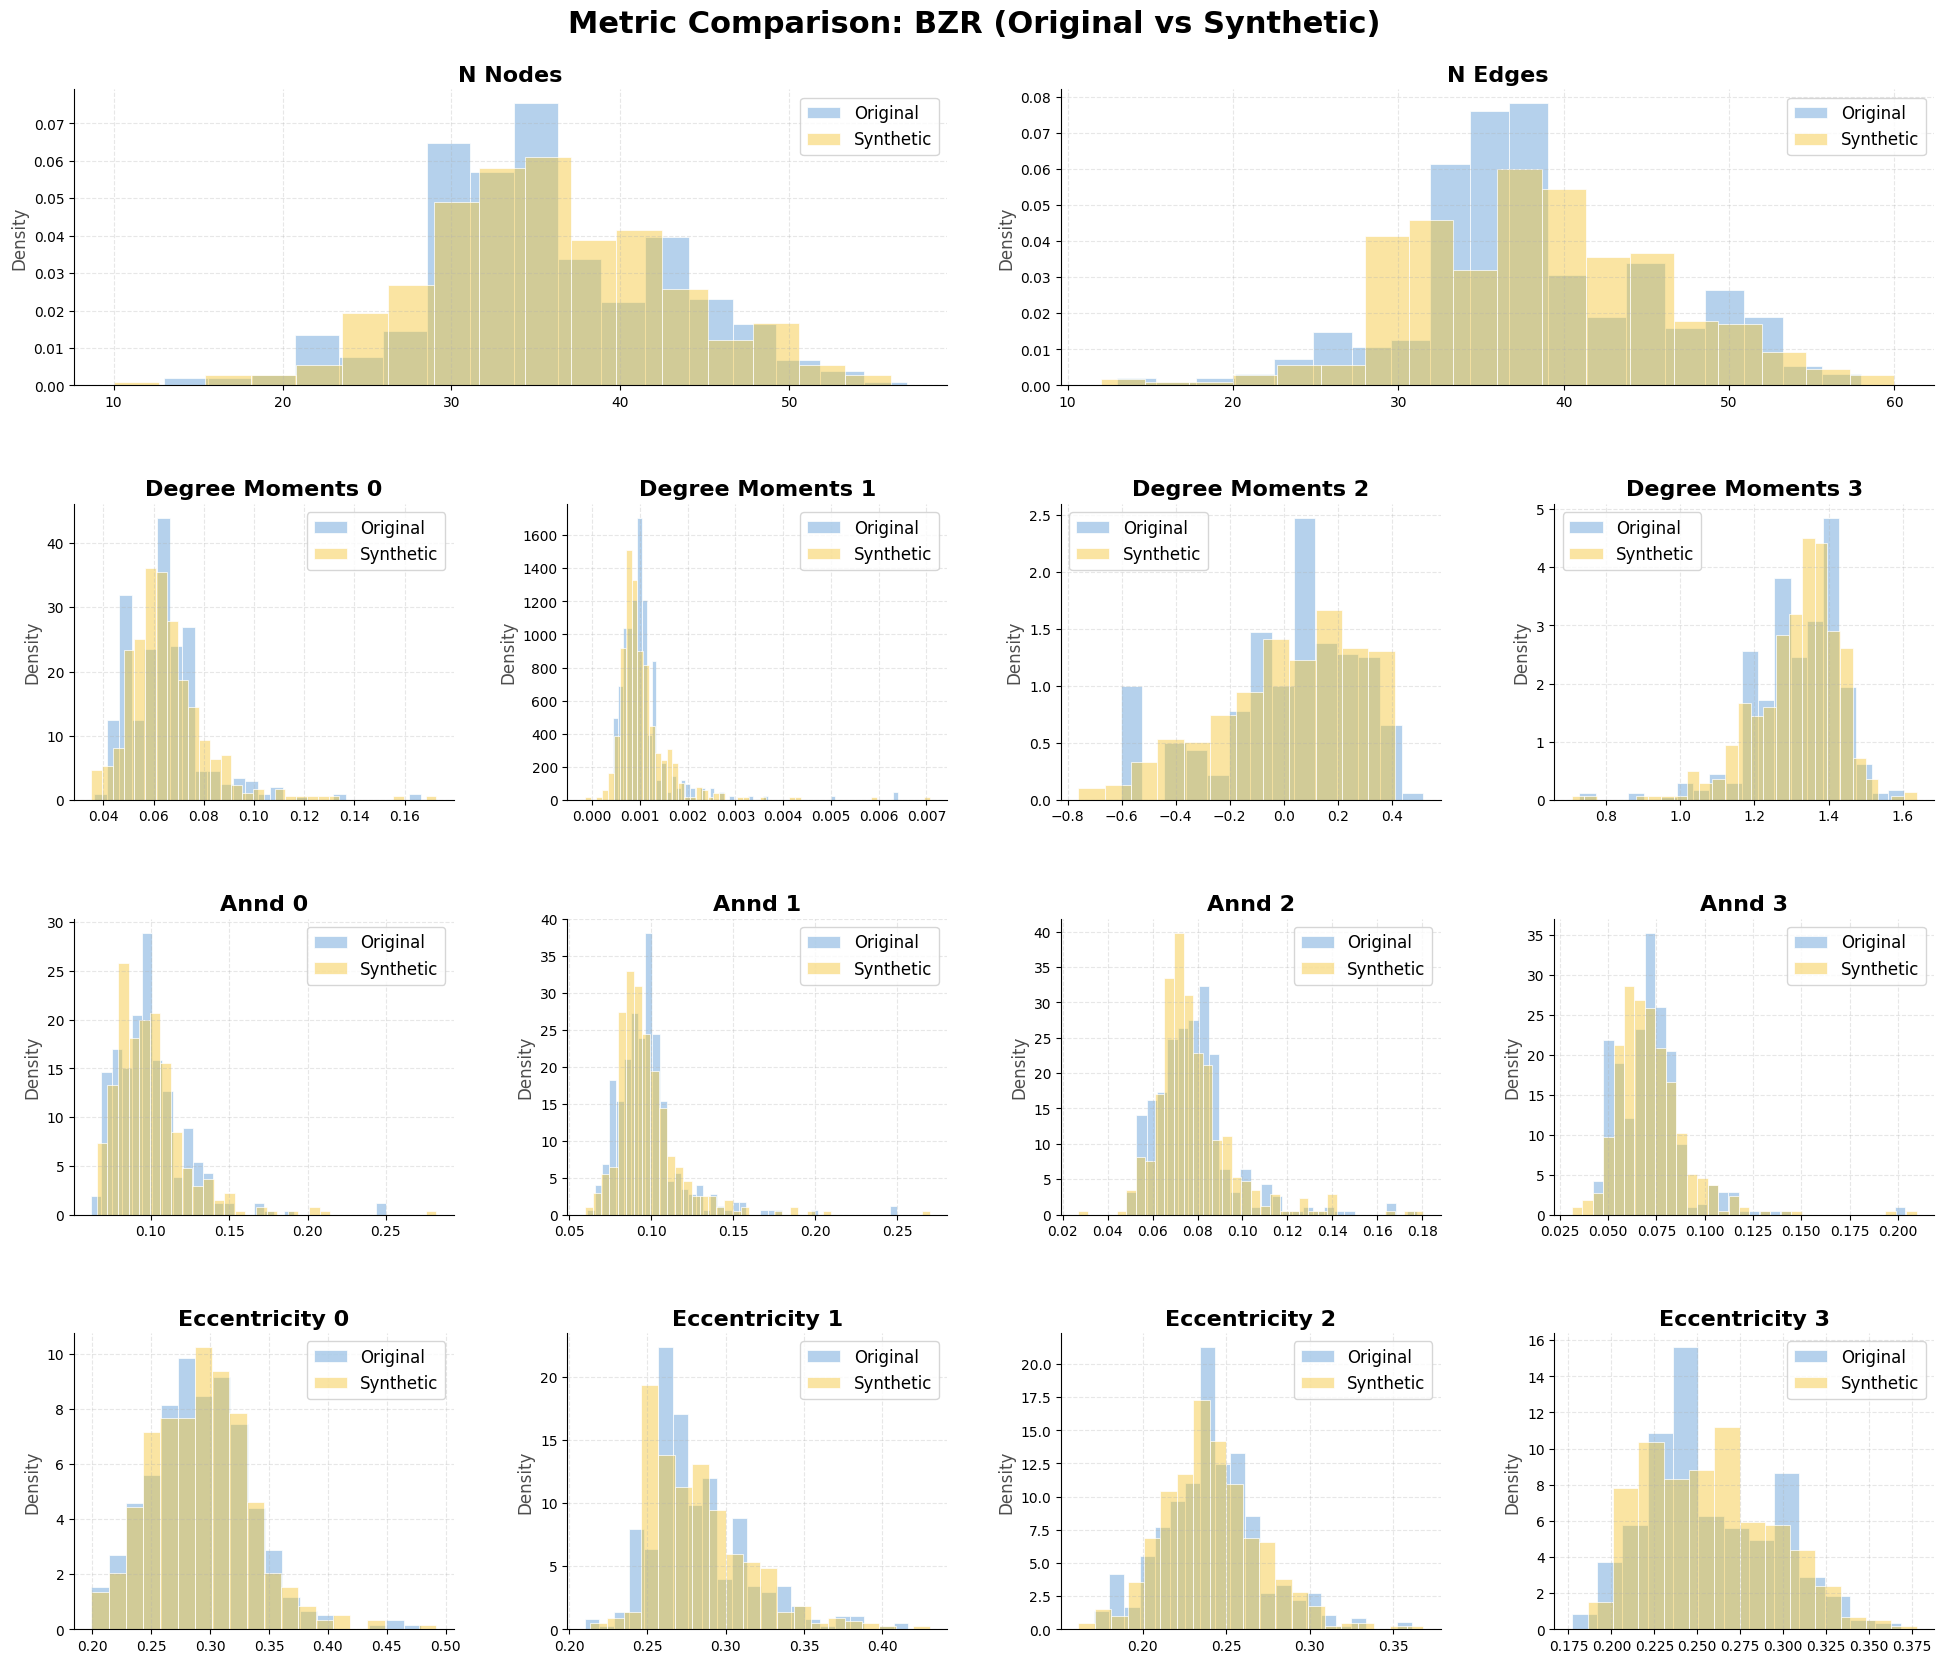

  Results for BZR:
    - Vector size:      112
    - Cosine Similarity: 1.0000
    - Classes:          [0, 1]

----------------------------------------
Dataset: MUTAG
----------------------------------------


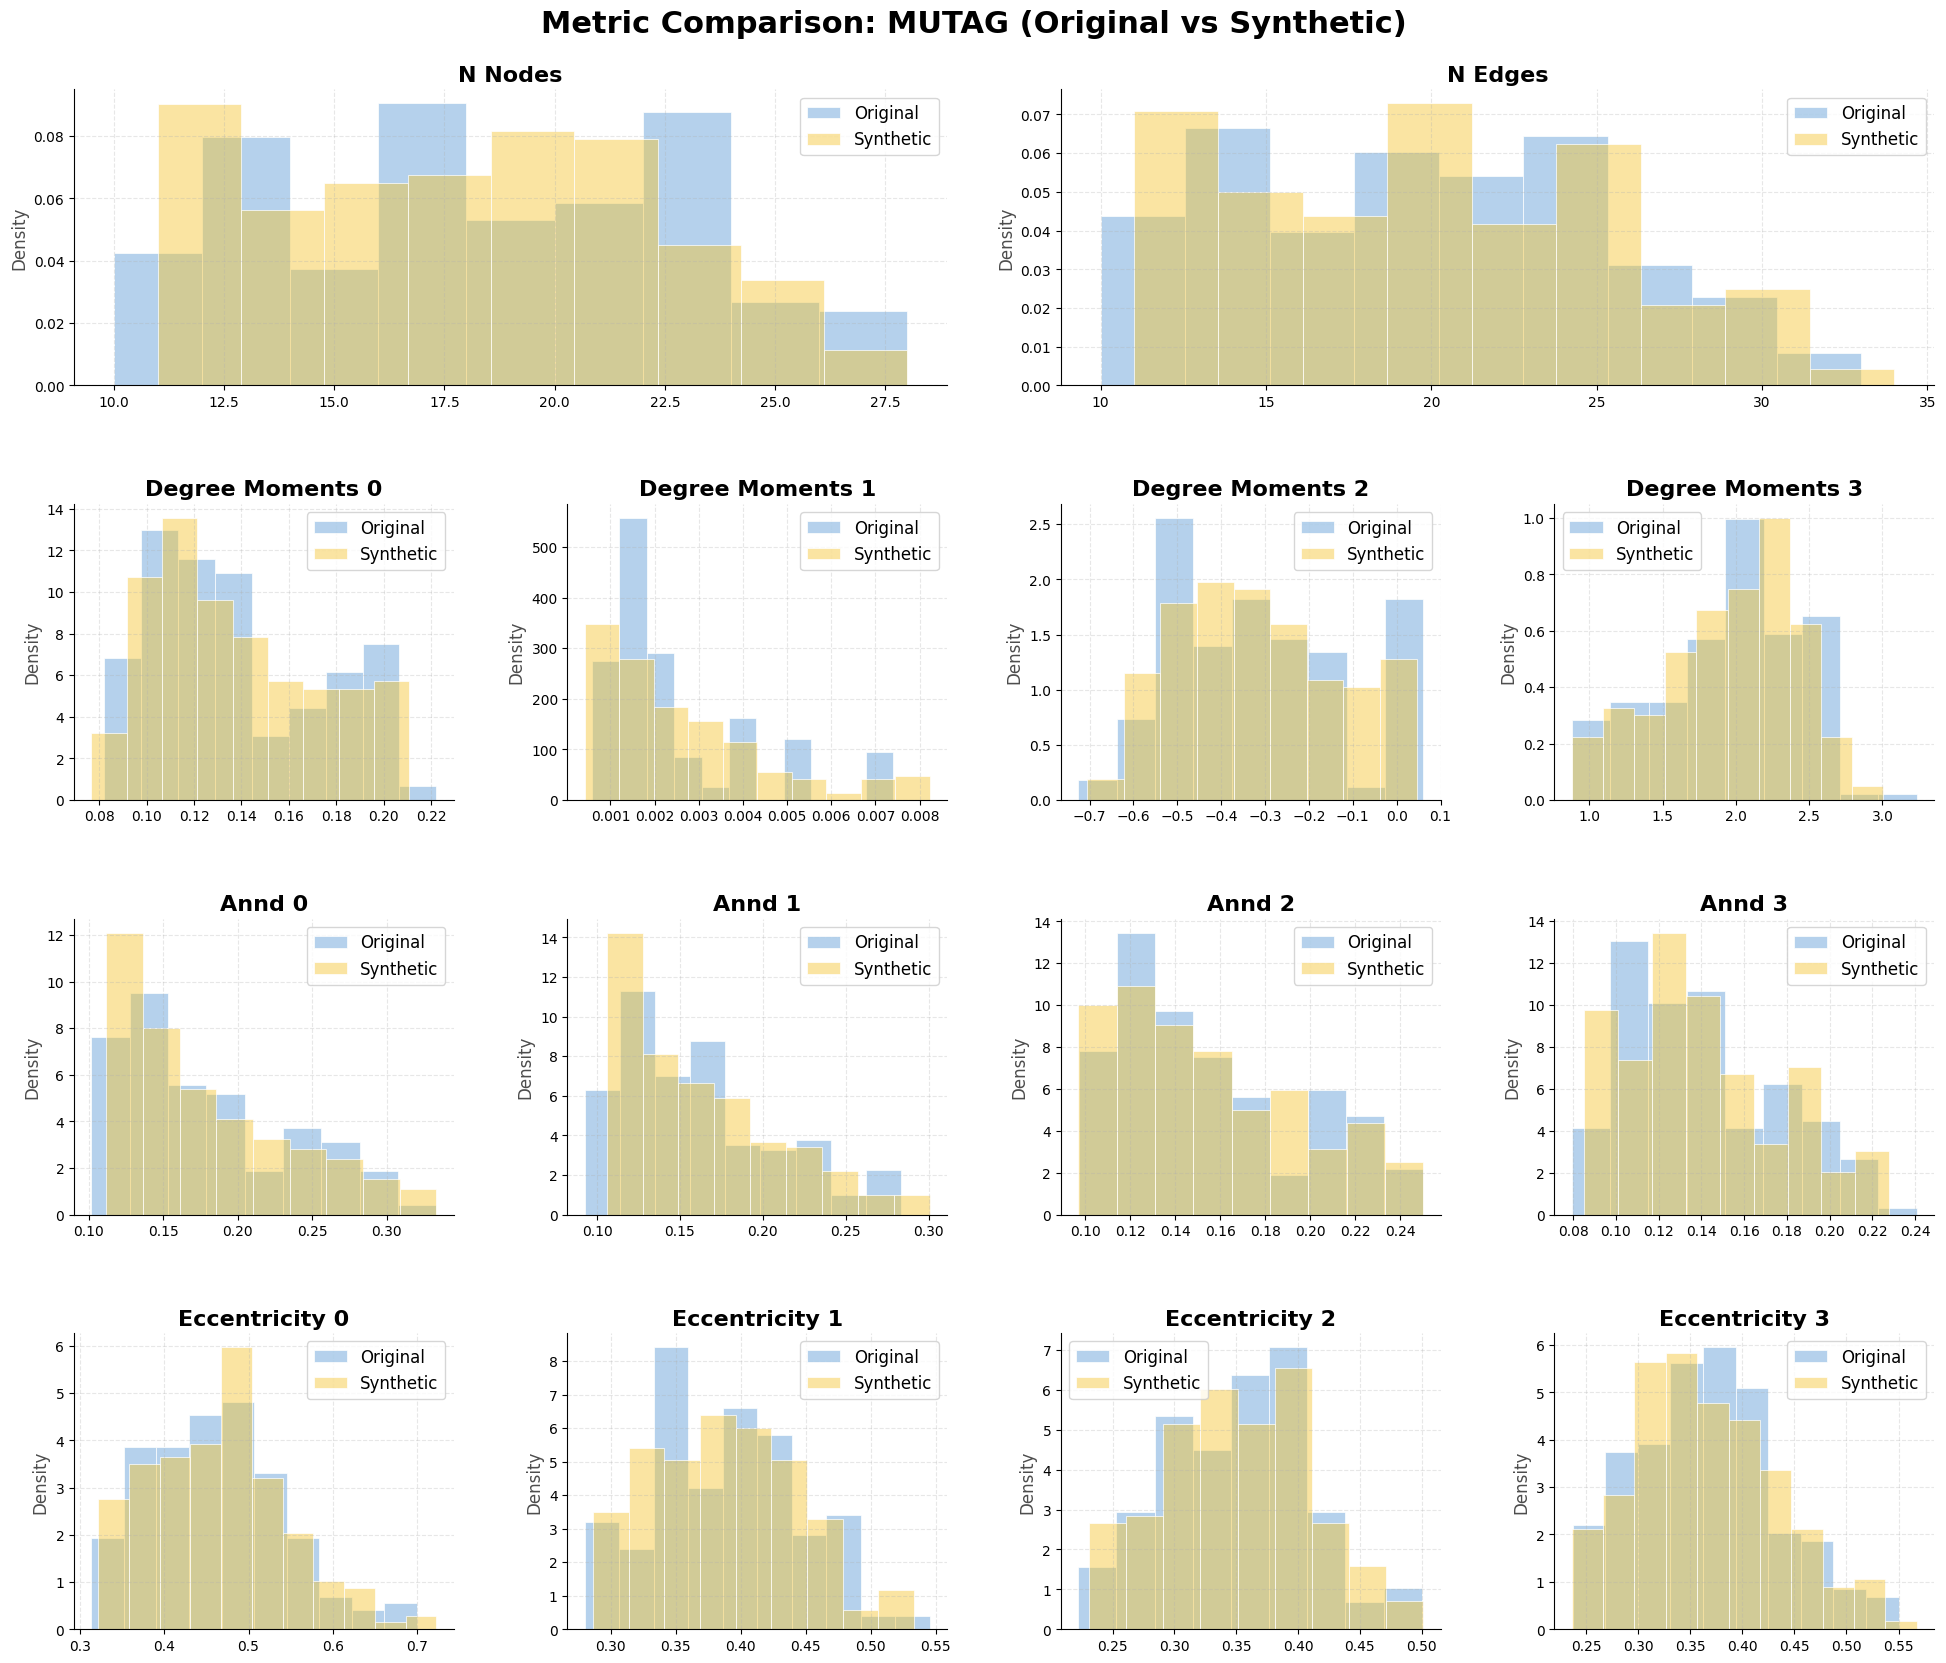

  Results for MUTAG:
    - Vector size:      112
    - Cosine Similarity: 0.9999
    - Classes:          [0, 1]


In [58]:
def plot_dataset_comparison(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str) -> None:
    """Plots distributions of all metrics for original vs synthetic datasets."""
    n_rows = 1 + (len(CONTINUOUS_FEATURES) + 3) // 4  # 1 row for discrete + rows for continuous
    
    fig = plt.figure(figsize=(24, 5 * n_rows))
    fig.suptitle(f"Metric Comparison: {dataset_name} (Original vs Synthetic)", fontsize=22, fontweight="bold", y=0.92)
    gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)
    
    # Define mapping of feature to subplot
    metrics_map = []
    
    # Row 0: Discrete features (spanning 2 columns each)
    metrics_map.append((DISCRETE_FEATURES[0], fig.add_subplot(gs[0, :2])))
    metrics_map.append((DISCRETE_FEATURES[1], fig.add_subplot(gs[0, 2:])))
    
    # Rows 1+: Continuous features (4 per row)
    for i, feat in enumerate(CONTINUOUS_FEATURES):
        row = (i // 4) + 1
        col = i % 4
        metrics_map.append((feat, fig.add_subplot(gs[row, col])))
        
    for feat, ax in metrics_map:
        if feat not in df_orig.columns:
            ax.axis("off")
            continue
            
        # Plot distributions
        for data, label, color in [(df_orig, "Original", "#5B9BD5"), (df_synth, "Synthetic", "#F5C431")]:
            sns.histplot(
                data=data, x=feat, ax=ax, label=label,
                color=color, alpha=0.45, stat="density", element="bars",
                linewidth=0.5, edgecolor="white"
            )
        
        ax.set_title(feat.replace("_", " ").title(), fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Density", fontsize=12, alpha=0.7)
        ax.legend(fontsize=12, frameon=True, facecolor="white", framealpha=0.8)
        ax.grid(True, linestyle="--", alpha=0.3)
        sns.despine(ax=ax)
        
    plt.show()

DATASET_EMBEDDINGS = {}

def vectorize_embedding(df_m):
    """Concatenate all moment arrays for all features and classes into a single vector."""
    feats = DISCRETE_FEATURES + CONTINUOUS_FEATURES
    return np.concatenate([np.concatenate(df_m[f].values) for f in feats])

# Pre-compute synthetic embeddings for comparison
print("Computing synthetic embeddings...")
synth_moms_list = []
for dataset_name in DATASETS:
    df_s_sub = df_synthetic[df_synthetic["dataset"] == dataset_name]
    if not df_s_sub.empty:
        synth_moms_list.append(compute_stat_embedding_per_class(df_s_sub, _compute_stat_moments, k=4))
df_synthetic_moments = pd.concat(synth_moms_list, ignore_index=True) if synth_moms_list else pd.DataFrame()

for dataset_name in DATASETS:
    print(f"\n{'-'*40}")
    print(f"Dataset: {dataset_name}")
    print(f"{'-'*40}")
    
    # 1. Get subsets
    df_orig_sub = df[df["dataset"] == dataset_name]
    df_synth_sub = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    # 2. Extract moments for comparison
    orig_moments = df_moments[df_moments["dataset"] == dataset_name]
    synth_moments = df_synthetic_moments[df_synthetic_moments["dataset"] == dataset_name]
    
    # 3. Fidelity Comparison (Vectorize embeddings)
    v_orig = vectorize_embedding(orig_moments)
    v_synth = vectorize_embedding(synth_moments)
    
    # Cosine Similarity
    norm_orig = np.linalg.norm(v_orig)
    norm_synth = np.linalg.norm(v_synth)
    cos_sim = np.dot(v_orig, v_synth) / (norm_orig * norm_synth) if norm_orig > 0 and norm_synth > 0 else 0
    
    # 4. Visualization
    plot_dataset_comparison(df_orig_sub, df_synth_sub, dataset_name)
    
    # Store results
    DATASET_EMBEDDINGS[dataset_name] = {
        "v_orig": v_orig,
        "v_synth": v_synth,
        "cos_sim": cos_sim
    }

    print(f"  Results for {dataset_name}:")
    print(f"    - Vector size:      {len(v_orig)}")
    print(f"    - Cosine Similarity: {cos_sim:.4f}")
    print(f"    - Classes:          {orig_moments['class_id'].tolist()}")

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

def evaluate_with_random_forest(
    df_orig: pd.DataFrame, 
    df_synth: pd.DataFrame,
    discrete_features: list[str],
    continuous_features: list[str]
) -> None:
    """
    Trains a Random Forest classifier to evaluate the datasets.
    Evaluates:
    1. Train on original, Test on original
    2. Train on synthetic, Test on synthetic
    3. Train on synthetic, Test on original
    Returns and prints the F1 scores.
    """
    features = discrete_features + continuous_features
    target = "class_id"
    
    # 1. Split datasets
    X_orig = df_orig[features]
    y_orig = df_orig[target]
    X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
        X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
    )
    
    X_synth = df_synth[features]
    y_synth = df_synth[target]
    X_synth_train, X_synth_test, y_synth_train, y_synth_test = train_test_split(
        X_synth, y_synth, test_size=0.2, random_state=42, stratify=y_synth
    )
    
    # 2. Train and evaluate on original
    rf_orig = RandomForestClassifier(random_state=42)
    rf_orig.fit(X_orig_train, y_orig_train)
    y_orig_pred = rf_orig.predict(X_orig_test)
    f1_orig = f1_score(y_orig_test, y_orig_pred, average="weighted")
    
    # 3. Train and evaluate on synthetic
    rf_synth = RandomForestClassifier(random_state=42)
    rf_synth.fit(X_synth_train, y_synth_train)
    y_synth_pred = rf_synth.predict(X_synth_test)
    f1_synth = f1_score(y_synth_test, y_synth_pred, average="weighted")
    
    # 4. Train on synthetic, test on original
    rf_cross = RandomForestClassifier(random_state=42)
    rf_cross.fit(X_synth_train, y_synth_train)
    y_cross_pred = rf_cross.predict(X_orig_test)
    f1_cross = f1_score(y_orig_test, y_cross_pred, average="weighted")
    
    print("--- Classifier Evaluation (F1 Score) ---")
    print(f"Train Orig  -> Test Orig:  {f1_orig:.4f}")
    print(f"Train Synth -> Test Synth: {f1_synth:.4f}")
    print(f"Train Synth -> Test Orig:  {f1_cross:.4f}")
    print("-" * 40)

print(f"\n{'='*50}")
print("SYSTEMATIC CLASSIFIER EVALUATION")
print(f"{'='*50}")

for dataset_name in DATASETS:
    print(f"\nProcessing {dataset_name}...")
    
    # 1. Get pre-computed data subsets
    df_orig_sub = df[df["dataset"] == dataset_name]
    df_synth_sub = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    # 2. Run Random Forest Evaluation
    evaluate_with_random_forest(df_orig_sub, df_synth_sub, DISCRETE_FEATURES, CONTINUOUS_FEATURES)


SYSTEMATIC CLASSIFIER EVALUATION

Processing BZR...


--- Classifier Evaluation (F1 Score) ---
Train Orig  -> Test Orig:  0.7831
Train Synth -> Test Synth: 0.8916
Train Synth -> Test Orig:  0.7471
----------------------------------------

Processing MUTAG...
--- Classifier Evaluation (F1 Score) ---
Train Orig  -> Test Orig:  0.7926
Train Synth -> Test Synth: 1.0000
Train Synth -> Test Orig:  0.8671
----------------------------------------
